# EDA ① 관세청 품목별·국가별 수출입실적 (A1) — 핵심 ① 「수출입 현황」

작성 2026-09-19 · **13개 기준 재실행 2026-09-22** · 산출물 4 「전처리 및 EDA 보고서」 중 관세청 편

| 항목 | 내용 |
|---|---|
| 원본 | `data/raw/customs/customs_all_<HS6>.csv` × 24 (관세청 OpenAPI `15100475`, `scripts/fetch_customs.py --all-countries`) |
| 기준표 | `data/reference/hs_whitelist.csv` — HS6 24개, 우선순위 1·2(**13개**)가 분석 대상, 3순위 11개는 배경(09-21 회의 M5로 R4 제외 → 19개 → 13개) |
| 기간 | 2016.01 ~ 2026.08. **공통 최신 완결연도 2025**, 2026은 1~8월 부분연도라 연간 실적처럼 쓰지 않는다 |
| 정제 규칙 | `docs/reference/data-cleaning-rules.md` §2-1 |

**해석 경계**(`idea-review.md` §3): 관세청 통계는 **국가 전체 수입·수출(민수 포함)** 이다. 이 노트북의 HHI·점유율을 "해외 의존율", "방산 수입 HHI"로 부르지 않는다. 리스크 예측·조기경보를 표방하지 않는다.

목차: 1 적재·점검 → 2 기술통계 → 3 추세 → 4 비교 → 5 구성 → 6 관계 → 7 공간 → 8 차이검정 → 9 상관분석 → 10 요약·한계

In [1]:
import sys, glob, platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
RAW = ROOT / "data" / "raw"
REF = ROOT / "data" / "reference"

# 한글 폰트: 맥 AppleGothic / 윈도 Malgun Gothic / 그 외 NanumGothic
plt.rcParams["font.family"] = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30, "display.width", 180, "display.float_format", "{:,.2f}".format)

# 품목군 색은 노트북 전체에서 고정
CAT_COLOR = {"반도체": "#2a6fdb", "전자부품": "#e07b39", "소재장비": "#5a9e6f"}
IMP, EXP = "#2a6fdb", "#d9534f"
LAST_FULL_YEAR = 2025

## 1. 적재·기본 점검

원본은 **수정하지 않고** 읽기만 한다. 금액·중량은 문자열로 읽은 뒤 숫자로 바꾸고, 변환 실패 건수를 확인한다.

In [2]:
wl = pd.read_csv(REF / "hs_whitelist.csv", dtype={"hs_code": str})
files = sorted(glob.glob(str(RAW / "customs" / "customs_all_*.csv")))
raw = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)

print(f"파일 수: {len(files)}  (화이트리스트 {len(wl)}개)")
print(f"원본 전체 행: {len(raw):,}  / 열 {raw.shape[1]}개")
print(f"총계행(is_total=1): {(raw.is_total == '1').sum():,}")
missing = set(wl.hs_code) - {Path(f).stem.split('_')[-1] for f in files}
print("화이트리스트 중 파일 없는 HS6:", missing or "없음")
raw.head(3)

파일 수: 24  (화이트리스트 24개)
원본 전체 행: 294,420  / 열 15개
총계행(is_total=1): 246
화이트리스트 중 파일 없는 HS6: 없음


,year,statCd,statCdCntnKor1,hsCd,statKor,expWgt,expDlr,impWgt,impDlr,balPayments,req_hs,req_cnty,req_year,fetched_at,is_total
0,총계,-,-,-,-,1490743,150612968,283525,424473627,-273860659,841191,ALL,2016,2026-09-14 22:31:21,1
1,2016.01,BE,벨기에,8411911000,항공기용,0,0,2,2281,-2281,841191,ALL,2016,2026-09-14 22:31:21,0
2,2016.01,CA,캐나다,8411911000,항공기용,0,0,14,62016,-62016,841191,ALL,2016,2026-09-14 22:31:21,0


In [3]:
d = raw[raw.is_total == "0"].copy()
for c in ["expWgt", "expDlr", "impWgt", "impDlr", "balPayments"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d["yr"] = d["year"].str[:4].astype(int)
d["mon"] = d["year"].str[5:7].astype(int)
d["hs6"] = d["hsCd"].str[:6]

checks = {
    "숫자 변환 실패(impDlr/expDlr)": int(d[["impDlr", "expDlr"]].isna().sum().sum()),
    "완전 중복 행": int(raw.duplicated().sum()),
    "상세행 키(hsCd·statCd·year) 중복": int(d.duplicated(["hsCd", "statCd", "year"]).sum()),
    "hsCd 앞 6자리 ≠ 요청 HS": int((d.hs6 != d.req_hs).sum()),
    "음수 금액": int((d[["impDlr", "expDlr"]] < 0).sum().sum()),
    "HS10 고유 수": d.hsCd.nunique(),
    "국가 고유 수": d.statCd.nunique(),
}
pd.Series(checks, name="값").to_frame()

,값
숫자 변환 실패(impDlr/expDlr),0
완전 중복 행,0
상세행 키(hsCd·statCd·year) 중복,0
hsCd 앞 6자리 ≠ 요청 HS,0
음수 금액,0
HS10 고유 수,211
국가 고유 수,237


In [4]:
d = d.merge(wl[["hs_code", "category", "priority", "axis", "name_ko"]], left_on="hs6", right_on="hs_code", how="left")
d["is_target"] = d["priority"].isin([1, 2])
d["is_partial_year"] = d["yr"] > LAST_FULL_YEAR

# 월 수 확인: 2026이 부분연도인지
print(d.groupby("yr")["mon"].nunique().rename("월 수").to_dict())

# 보고 5단계 (data-cleaning-rules §4 양식)
full = d[~d.is_partial_year]
stage = pd.DataFrame({
    "단계": ["① 원본 전체", "② 상세행(총계행 제외)", "③ 완결연도 2016~2025", "④ 분석 대상 HS6(우선순위 1·2)", "⑤ 최신 완결연도 2025"],
    "행 수": [len(raw), len(d), len(full), int(full.is_target.sum()), int(full[full.is_target & (full.yr == 2025)].shape[0])],
    "HS6 수": [raw.req_hs.nunique(), d.hs6.nunique(), full.hs6.nunique(), full[full.is_target].hs6.nunique(), full[full.is_target & (full.yr == 2025)].hs6.nunique()],
})
stage

{2016: 12, 2017: 12, 2018: 12, 2019: 12, 2020: 12, 2021: 12, 2022: 12, 2023: 12, 2024: 12, 2025: 12, 2026: 8}


,단계,행 수,HS6 수
0,① 원본 전체,294420,24
1,② 상세행(총계행 제외),294174,24
2,③ 완결연도 2016~2025,276362,24
3,④ 분석 대상 HS6(우선순위 1·2),146817,13
4,⑤ 최신 완결연도 2025,14486,13


**판정** — 수량: 원본 294,420행으로 1만 건을 크게 넘는다(단, 이 프로젝트의 1만 건 요건 데이터는 국내조달 계약정보다) / 최신 연도: 2025 완결, 2026 부분 / 주제 적합성: HS6 24개는 규칙(R1~R4)으로 고른 **민군 겸용 품목군**이지 방산 전용 품목이 아니다 / 연결 가능성: 화이트리스트와 `hs6`로 100% 연결(불일치 0).

행은 **HS10 × 국가 × 월** 단위라서, 분석에서는 **HS6 × 국가 × 연** 또는 **HS6 × 연**으로 합산해 쓴다.

In [5]:
# 분석용 집계 테이블 3종
hs_cty_yr = full.groupby(["hs6", "category", "priority", "is_target", "statCd", "yr"], as_index=False)[["impDlr", "expDlr"]].sum()
hs_yr = full.groupby(["hs6", "category", "priority", "is_target", "name_ko", "yr"], as_index=False)[["impDlr", "expDlr"]].sum()
cat_yr = full.groupby(["category", "yr"], as_index=False)[["impDlr", "expDlr"]].sum()

def hhi_table(df, col):
    # HS6×연도별 국가 점유율 HHI(0~10,000), 1위국·1위 점유율, 거래국 수. DB 뷰 v_hhi_hs6_year 와 같은 정의
    g = df[df[col] > 0].copy()
    g["share"] = g[col] / g.groupby(["hs6", "yr"])[col].transform("sum")
    g = g.sort_values(["hs6", "yr", "share"], ascending=[True, True, False])
    out = g.groupby(["hs6", "yr"]).agg(
        hhi=("share", lambda s: float(((s * 100) ** 2).sum())),
        top1=("statCd", "first"), top1_share=("share", "first"), n_country=("statCd", "size"))
    return out.reset_index()

hhi_imp = hhi_table(hs_cty_yr, "impDlr").add_suffix("_imp").rename(columns={"hs6_imp": "hs6", "yr_imp": "yr"})
hhi_exp = hhi_table(hs_cty_yr, "expDlr").add_suffix("_exp").rename(columns={"hs6_exp": "hs6", "yr_exp": "yr"})
print(hs_cty_yr.shape, hs_yr.shape, hhi_imp.shape)

(16569, 8) (222, 8) (222, 6)


## 2. 기술통계

### 2-1. HS6 × 국가 × 연 수입액 분포 (2025, 분석 대상 13개)

금액은 소수 국가·품목에 몰려 **오른쪽으로 크게 치우친 분포**가 예상된다. 평균·표준편차보다 중앙값·사분위를 함께 본다.

In [6]:
t25 = hs_cty_yr[(hs_cty_yr.yr == 2025) & hs_cty_yr.is_target]
desc = pd.DataFrame({
    "수입액(USD)": t25.loc[t25.impDlr > 0, "impDlr"].describe(),
    "수출액(USD)": t25.loc[t25.expDlr > 0, "expDlr"].describe(),
}).T
desc["왜도"] = [stats.skew(t25.loc[t25.impDlr > 0, "impDlr"]), stats.skew(t25.loc[t25.expDlr > 0, "expDlr"])]
desc["0인 조합 수"] = [(t25.impDlr == 0).sum(), (t25.expDlr == 0).sum()]
desc

,count,mean,std,min,25%,50%,75%,max,왜도,0인 조합 수
수입액(USD),653.00,"73,226,940.77","793,371,099.75",1.00,"6,508.00","157,007.00","2,542,355.00","18,613,268,930.00",20.39,309
수출액(USD),791.00,"76,689,906.66","625,977,862.84",1.00,"6,160.00","111,500.00","1,776,248.00","9,875,569,064.00",12.33,171


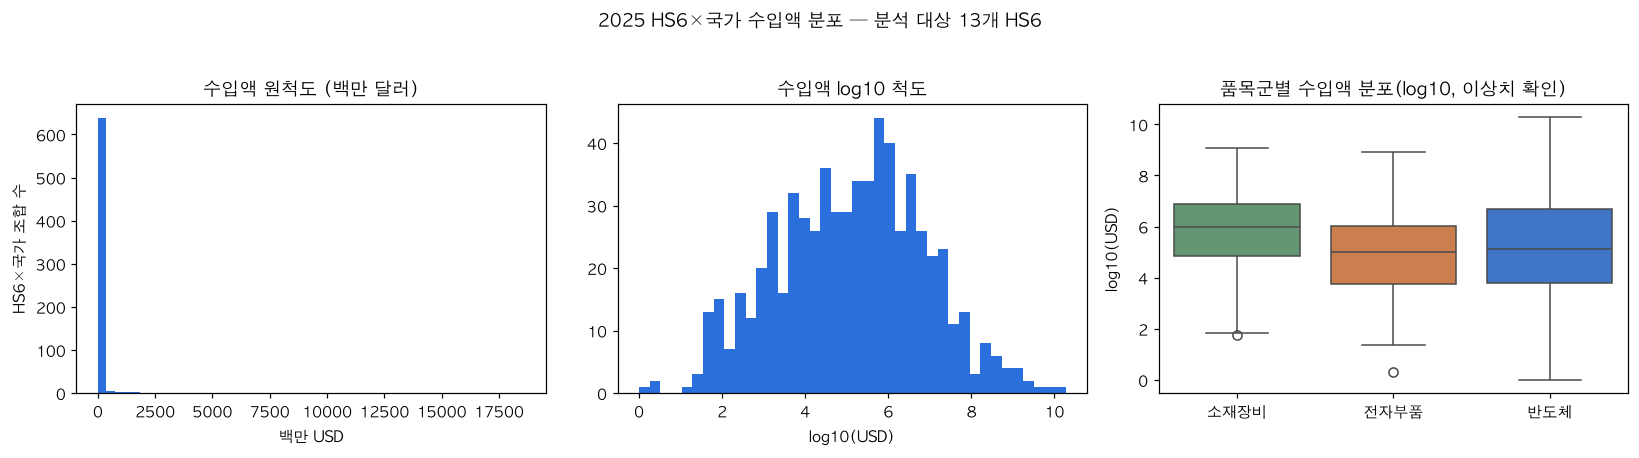

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
v = t25.loc[t25.impDlr > 0, "impDlr"]
ax[0].hist(v / 1e6, bins=50, color=IMP); ax[0].set(title="수입액 원척도 (백만 달러)", xlabel="백만 USD", ylabel="HS6×국가 조합 수")
ax[1].hist(np.log10(v), bins=40, color=IMP); ax[1].set(title="수입액 log10 척도", xlabel="log10(USD)")
sns.boxplot(data=t25[t25.impDlr > 0].assign(log_imp=lambda x: np.log10(x.impDlr)), x="category", y="log_imp",
            hue="category", palette=CAT_COLOR, legend=False, ax=ax[2])
ax[2].set(title="품목군별 수입액 분포(log10, 이상치 확인)", xlabel="", ylabel="log10(USD)")
plt.suptitle("2025 HS6×국가 수입액 분포 — 분석 대상 13개 HS6", y=1.03); plt.tight_layout(); plt.show()

### 2-2. HS6별 2025 요약표 (분석 대상 13개)

수입·수출을 **같은 표에 나란히** 둔다(화면 ①의 동등 배치 원칙). CAGR은 2016→2025 9년 연평균 증가율.

In [8]:
def cagr(s):
    a, b = s.get(2016), s.get(2025)
    return (b / a) ** (1 / 9) - 1 if a and b and a > 0 else np.nan

base = hs_yr[hs_yr.is_target].pivot_table(index=["hs6", "name_ko", "category", "priority"], columns="yr", values="impDlr")
base_e = hs_yr[hs_yr.is_target].pivot_table(index=["hs6", "name_ko", "category", "priority"], columns="yr", values="expDlr")
summ = pd.DataFrame({
    "수입액_2025(백만$)": base[2025] / 1e6,
    "수출액_2025(백만$)": base_e[2025] / 1e6,
    "수입CAGR_16_25": base.apply(cagr, axis=1),
    "수출CAGR_16_25": base_e.apply(cagr, axis=1),
}).reset_index()
summ["무역수지비(수출-수입)/(수출+수입)"] = (summ["수출액_2025(백만$)"] - summ["수입액_2025(백만$)"]) / (summ["수출액_2025(백만$)"] + summ["수입액_2025(백만$)"])
h25 = hhi_imp[hhi_imp.yr == 2025].merge(hhi_exp[hhi_exp.yr == 2025], on=["hs6", "yr"])
summ = summ.merge(h25.drop(columns="yr"), on="hs6")
summ = summ.sort_values("수입액_2025(백만$)", ascending=False).reset_index(drop=True)
summ.style.format({c: "{:,.1f}" for c in ["수입액_2025(백만$)", "수출액_2025(백만$)", "hhi_imp", "hhi_exp"]}
                  | {c: "{:.1%}" for c in ["수입CAGR_16_25", "수출CAGR_16_25", "top1_share_imp", "top1_share_exp"]}
                  | {"무역수지비(수출-수입)/(수출+수입)": "{:+.2f}"})

,hs6,name_ko,category,priority,수입액_2025(백만$),수출액_2025(백만$),수입CAGR_16_25,수출CAGR_16_25,무역수지비(수출-수입)/(수출+수입),hhi_imp,top1_imp,top1_share_imp,n_country_imp,hhi_exp,top1_exp,top1_share_exp,n_country_exp
0,854231,프로세서·컨트롤러(집적회로),반도체,1,"33,585.8","36,684.8",7.3%,8.9%,+0.04,"3,492.4",TW,55.4%,67,"1,788.0",CN,26.9%,69
1,854239,기타 집적회로,반도체,1,"8,356.4","10,993.7",7.2%,14.2%,+0.14,"2,415.4",TW,43.5%,86,"1,944.4",TW,26.2%,64
2,852990,통신·레이더 기기 부분품,전자부품,1,"2,106.0","9,897.5",11.7%,5.4%,+0.65,"3,142.5",CN,39.4%,77,"5,037.7",CN,69.3%,108
3,841191,터보제트·터보프로펠러 부분품,소재장비,1,"1,506.1",826.3,15.1%,20.8%,-0.29,"5,886.8",US,76.4%,37,"2,458.6",US,44.3%,33
4,880730,항공기·헬리콥터 부분품,소재장비,2,745.2,"1,546.9",nan%,nan%,+0.35,"4,398.9",US,64.6%,51,"2,312.7",US,43.1%,66
5,852610,레이더 기기,전자부품,1,449.5,143.8,10.0%,30.6%,-0.52,"2,328.5",SG,43.2%,42,"1,564.5",US,33.4%,71
6,854233,증폭기(집적회로),반도체,1,297.9,168.8,10.1%,17.8%,-0.28,"1,852.1",CN,28.6%,40,"3,601.5",VN,58.6%,46
7,852910,안테나·반사식 안테나와 그 부분품,전자부품,2,256.7,182.8,-2.2%,-0.3%,-0.17,"1,870.2",VN,30.9%,61,797.4,VN,19.1%,107
8,901420,항공·우주용 항행기기,전자부품,1,237.5,34.3,9.5%,13.2%,-0.75,"5,774.4",US,73.4%,27,"1,786.5",AE,30.3%,25
9,901480,기타 항행용 기기,전자부품,2,118.2,25.5,-4.9%,-1.3%,-0.65,"1,870.5",US,33.7%,39,"1,133.3",SA,21.0%,35


## 3. 추세 — 품목군별 연간 수입·수출 (2016~2025)

2026(1~8월)은 연간 실적과 한 선에 잇지 않는다. 월별 흐름은 3-2에서 12개월 이동평균으로 따로 본다.

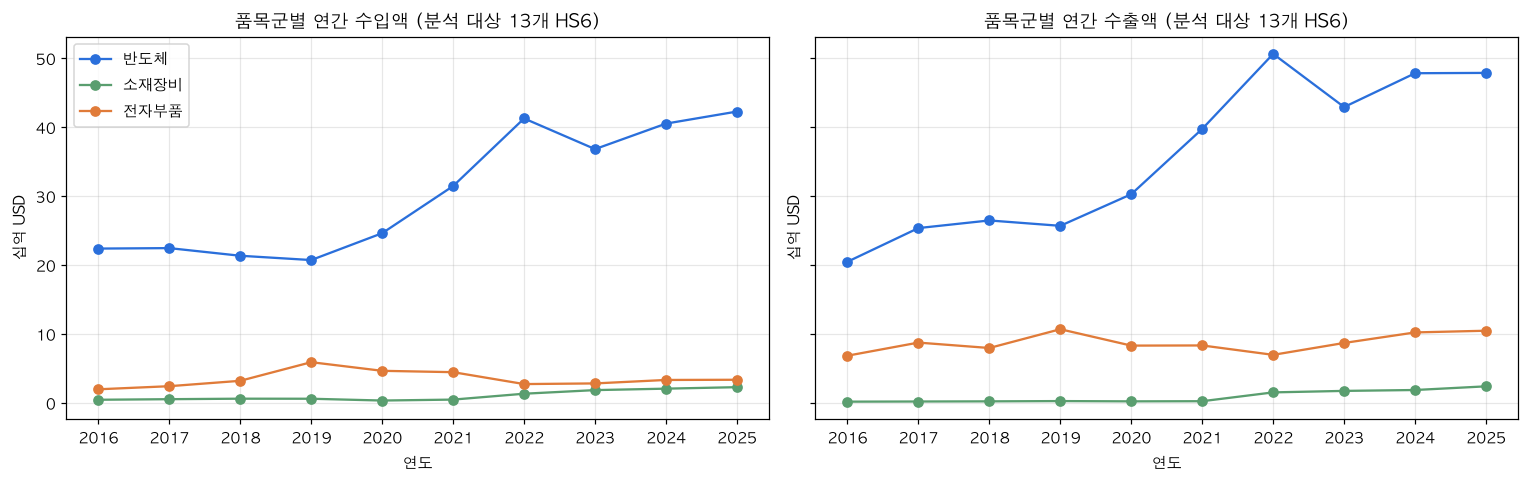

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
tgt = hs_yr[hs_yr.is_target].groupby(["category", "yr"], as_index=False)[["impDlr", "expDlr"]].sum()
for i, (col, ttl) in enumerate([("impDlr", "수입액"), ("expDlr", "수출액")]):
    for cat, g in tgt.groupby("category"):
        ax[i].plot(g.yr, g[col] / 1e9, marker="o", label=cat, color=CAT_COLOR[cat])
    ax[i].set(title=f"품목군별 연간 {ttl} (분석 대상 13개 HS6)", xlabel="연도", ylabel="십억 USD")
    ax[i].grid(alpha=.3); ax[i].set_xticks(range(2016, 2026))
ax[0].legend(); plt.tight_layout(); plt.show()

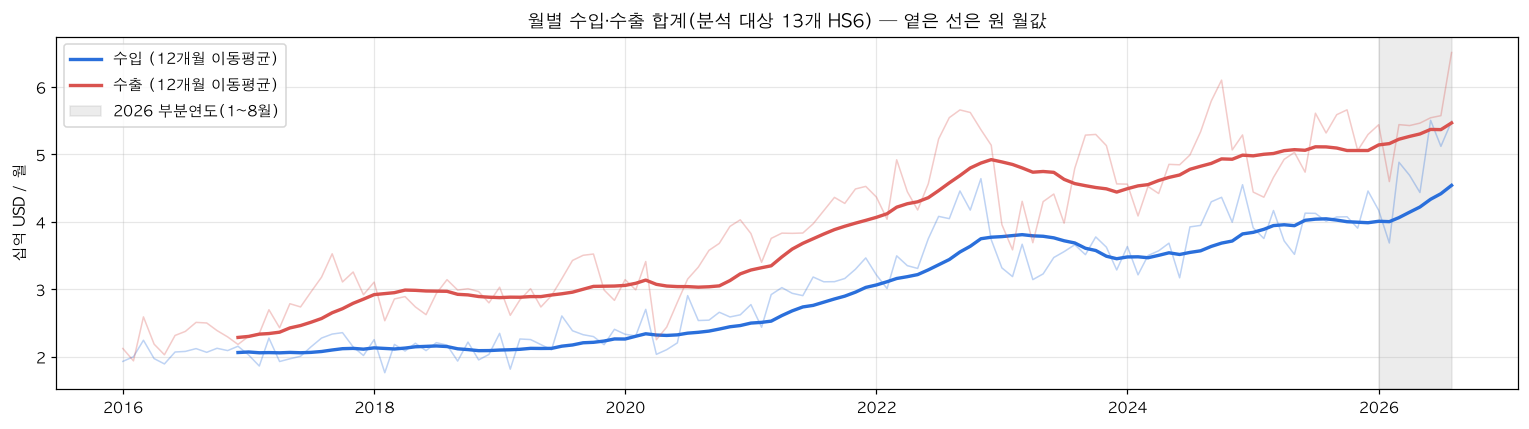

In [10]:
# 3-2. 월별 합계(분석 대상) — 12개월 이동평균으로 계절성 제거. 2026은 부분연도 구간 음영
mon = d[d.is_target].groupby(["yr", "mon"], as_index=False)[["impDlr", "expDlr"]].sum()
mon["date"] = pd.to_datetime(dict(year=mon.yr, month=mon.mon, day=1))
mon = mon.sort_values("date").set_index("date")
fig, ax = plt.subplots(figsize=(14, 4))
for col, c, lab in [("impDlr", IMP, "수입"), ("expDlr", EXP, "수출")]:
    ax.plot(mon.index, mon[col] / 1e9, color=c, alpha=.3, lw=1)
    ax.plot(mon.index, mon[col].rolling(12).mean() / 1e9, color=c, lw=2.2, label=f"{lab} (12개월 이동평균)")
ax.axvspan(pd.Timestamp("2026-01-01"), mon.index.max(), color="grey", alpha=.15, label="2026 부분연도(1~8월)")
ax.set(title="월별 수입·수출 합계(분석 대상 13개 HS6) — 옅은 선은 원 월값", ylabel="십억 USD / 월"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. 비교 — 2025 HS6별 수입 vs 수출 (동등 배치)

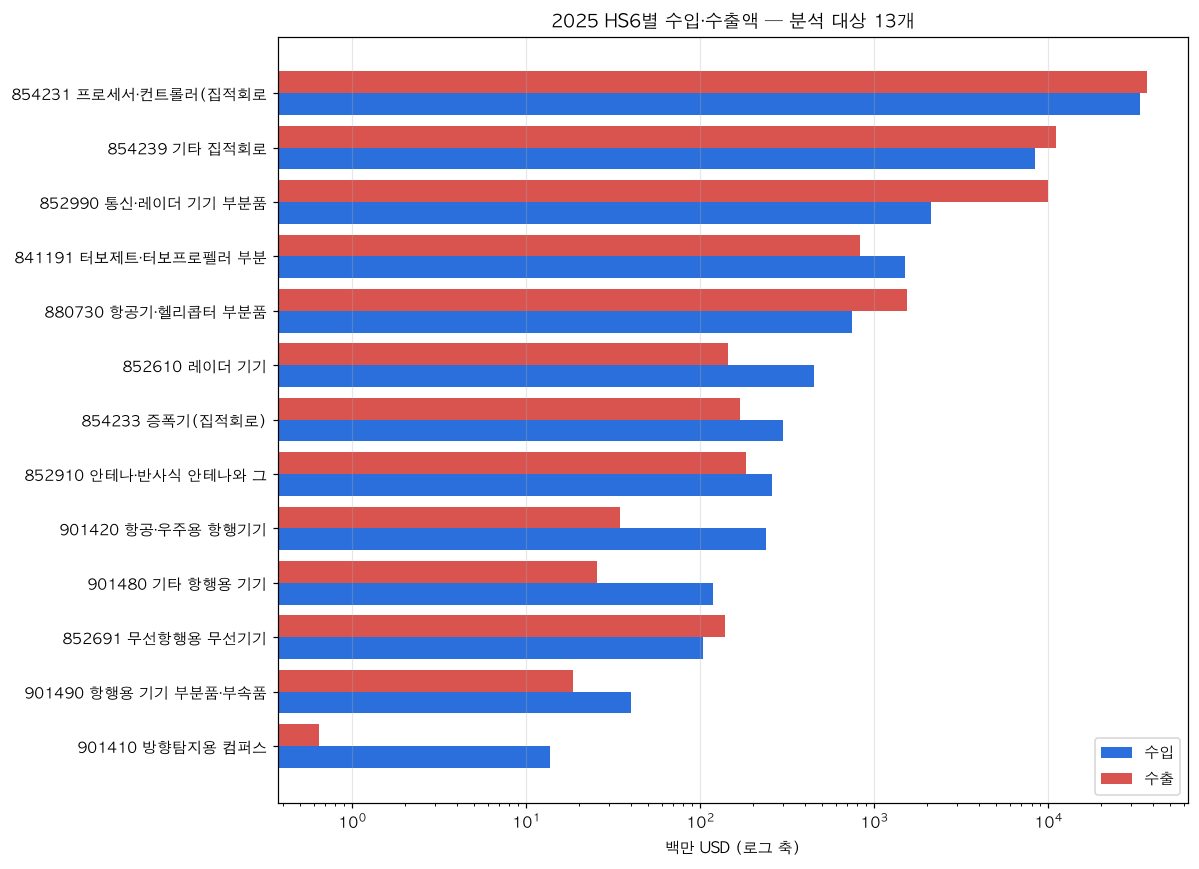

In [11]:
s = summ.sort_values("수입액_2025(백만$)")
y = np.arange(len(s))
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(y - .2, s["수입액_2025(백만$)"], height=.4, color=IMP, label="수입")
ax.barh(y + .2, s["수출액_2025(백만$)"], height=.4, color=EXP, label="수출")
ax.set_yticks(y, [f"{h} {n[:14]}" for h, n in zip(s.hs6, s.name_ko)])
ax.set_xscale("log"); ax.set(xlabel="백만 USD (로그 축)", title="2025 HS6별 수입·수출액 — 분석 대상 13개")
ax.legend(); ax.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

## 5. 구성 — 품목군별 수입 상대국 구성과 HHI (2025)

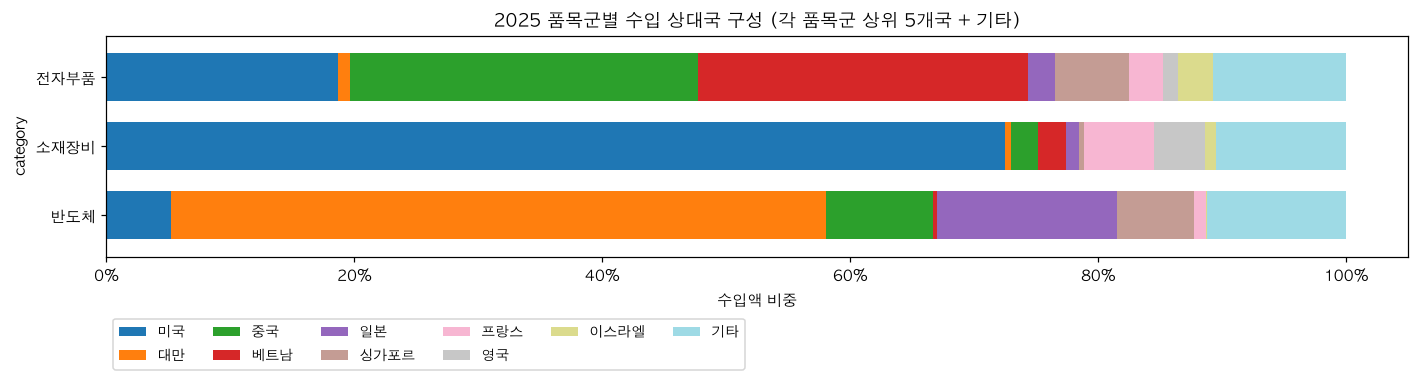

국가,미국,대만,중국,베트남,일본,싱가포르,프랑스,영국,이스라엘,기타
category,,,,,,,,,,
반도체,5.20,52.80,8.60,0.30,14.50,6.20,1.00,0.00,0.10,11.20
소재장비,72.50,0.50,2.20,2.30,1.00,0.40,5.60,4.10,0.90,10.50
전자부품,18.70,1.00,28.10,26.60,2.10,5.90,2.80,1.20,2.80,10.80


In [12]:
cty = pd.read_csv(REF / "country_ref.csv")
name = dict(zip(cty.statCd, cty.name_ko))
c25 = hs_cty_yr[(hs_cty_yr.yr == 2025) & hs_cty_yr.is_target].groupby(["category", "statCd"], as_index=False)["impDlr"].sum()
c25["share"] = c25.impDlr / c25.groupby("category").impDlr.transform("sum")
top = c25.sort_values("share", ascending=False).groupby("category").head(5)
keep = set(top.statCd)
c25["국가"] = np.where(c25.statCd.isin(keep), c25.statCd.map(name).fillna(c25.statCd), "기타")
comp = c25.groupby(["category", "국가"]).share.sum().unstack(fill_value=0)
comp = comp[[c for c in comp.sum().sort_values(ascending=False).index if c != "기타"] + ["기타"]]
ax = comp.plot.barh(stacked=True, figsize=(13, 3.8), colormap="tab20", width=.7)
ax.set(title="2025 품목군별 수입 상대국 구성 (각 품목군 상위 5개국 + 기타)", xlabel="수입액 비중")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(ncol=6, bbox_to_anchor=(0, -.25), loc="upper left", fontsize=9); plt.tight_layout(); plt.show()
(comp * 100).round(1)

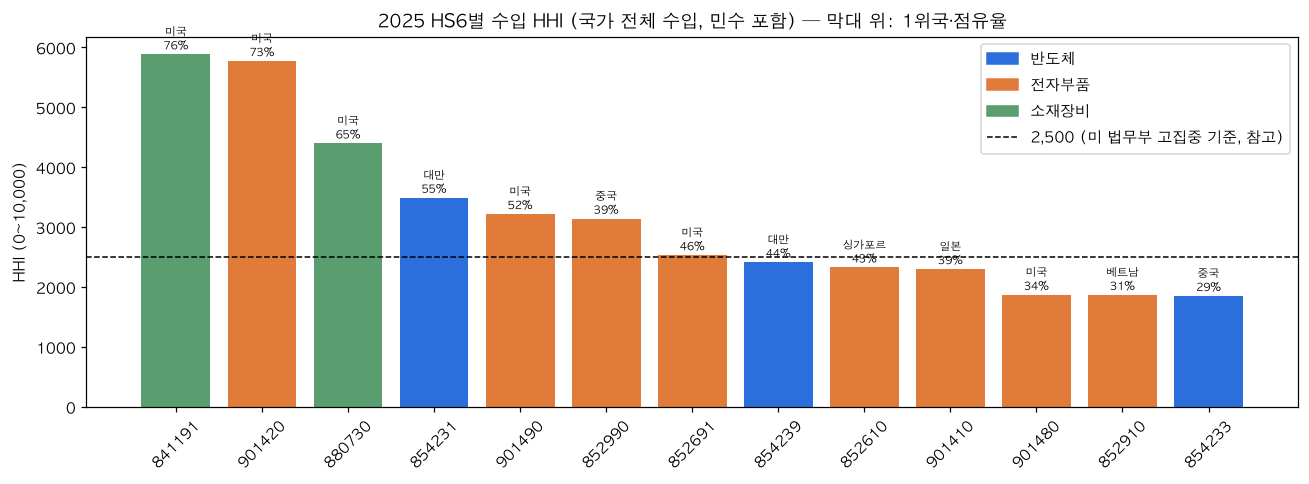

In [13]:
s = summ.sort_values("hhi_imp", ascending=False)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(s.hs6, s.hhi_imp, color=[CAT_COLOR[c] for c in s.category])
line = ax.axhline(2500, ls="--", color="k", lw=1, label="2,500 (미 법무부 고집중 기준, 참고)")
for i, (h, t, sh) in enumerate(zip(s.hhi_imp, s.top1_imp, s.top1_share_imp)):
    ax.text(i, h + 80, f"{name.get(t, t)}\n{sh:.0%}", ha="center", fontsize=7.5)
ax.set(title="2025 HS6별 수입 HHI (국가 전체 수입, 민수 포함) — 막대 위: 1위국·점유율", ylabel="HHI (0~10,000)")
ax.tick_params(axis="x", rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in CAT_COLOR.items()] + [line]); plt.tight_layout(); plt.show()

## 6. 관계

### 6-1. 수입 규모 vs 수입 집중도 (HS6, 2025)

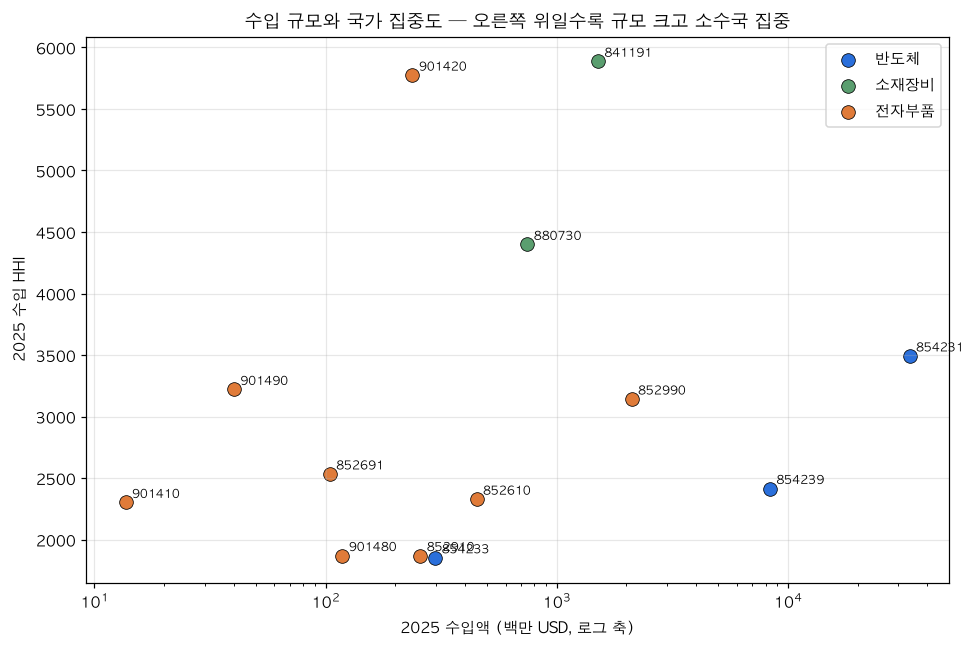

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
for cat, g in summ.groupby("category"):
    ax.scatter(g["수입액_2025(백만$)"], g.hhi_imp, s=80, color=CAT_COLOR[cat], label=cat, edgecolor="k", lw=.5)
for _, r in summ.iterrows():
    ax.annotate(r.hs6, (r["수입액_2025(백만$)"], r.hhi_imp), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log"); ax.set(xlabel="2025 수입액 (백만 USD, 로그 축)", ylabel="2025 수입 HHI", title="수입 규모와 국가 집중도 — 오른쪽 위일수록 규모 크고 소수국 집중")
ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()

### 6-2. 반도체 수입 vs 국내 전자부품 생산지수 (월별)

KOSIS 광공업생산지수 C26(전자부품·컴퓨터·영상·음향·통신장비, 2020=100) 원지수와 반도체 분석 대상 HS6의 월 수입액을 나란히 본다. **지수와 금액은 단위가 달라 합산·직접 비교하지 않고**(`data-cleaning-rules` §1-10), 2020 평균=100으로 정규화한 추세만 겹친다.

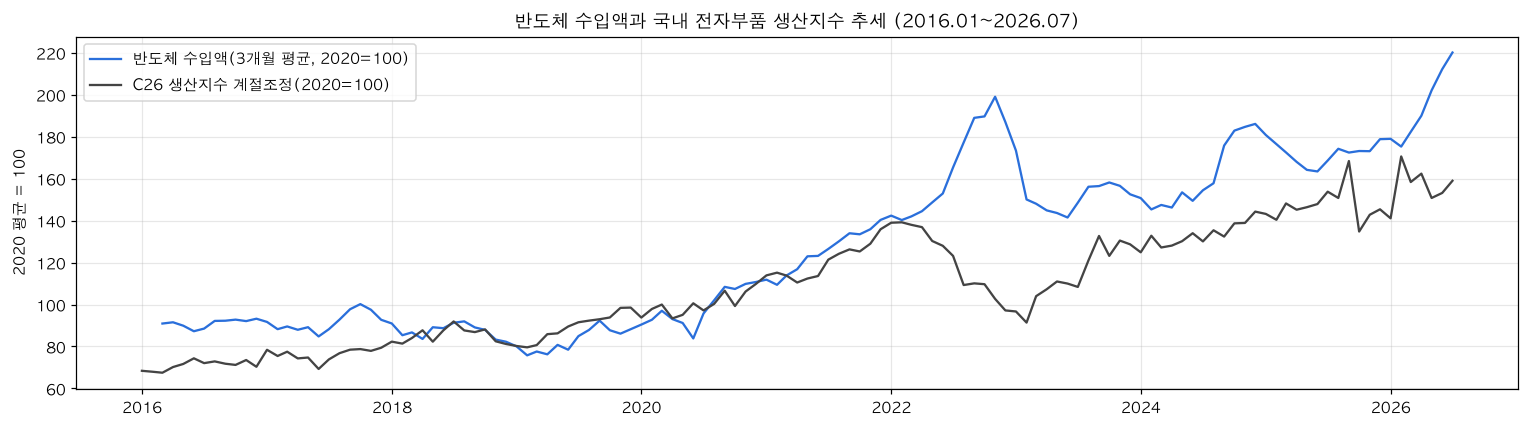

겹치는 월 수: 127


In [15]:
k = pd.read_csv(RAW / "kosis" / "kosis_101_production_index_c26_201601_202607.csv", encoding="cp949", header=None)
vals = k.iloc[2, 2:].astype(float).values
periods = k.iloc[0, 2:].astype(str).str.extract(r"M(\d{6})")[0].values
kind = k.iloc[1, 2:].astype(str).str[:3].values       # T10 원지수 / T20 계절조정
kosis = pd.DataFrame({"ym": periods, "kind": kind, "v": vals}).pivot(index="ym", columns="kind", values="v")
kosis.index = pd.to_datetime(kosis.index, format="%Y%m")
kosis.columns = ["prod_raw", "prod_sa"]

semi = d[d.is_target & (d.category == "반도체")].groupby(["yr", "mon"], as_index=False).impDlr.sum()
semi.index = pd.to_datetime(dict(year=semi.yr, month=semi.mon, day=1))
m = kosis.join(semi.impDlr.rename("semi_imp"), how="inner")
norm = m / m.loc["2020"].mean() * 100
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(norm.index, norm.semi_imp.rolling(3).mean(), color=IMP, label="반도체 수입액(3개월 평균, 2020=100)")
ax.plot(norm.index, norm.prod_sa, color="#444", label="C26 생산지수 계절조정(2020=100)")
ax.set(title=f"반도체 수입액과 국내 전자부품 생산지수 추세 ({m.index.min():%Y.%m}~{m.index.max():%Y.%m})", ylabel="2020 평균 = 100")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("겹치는 월 수:", len(m))

## 7. 공간

### 7-1. 2025 수입 상대국 지도 (분석 대상 13개 HS6 합계)

원 크기 = 수입액. 좌표는 `data/reference/country_ref.csv`(국가 중심점). `ZZ`(기타국)는 좌표가 없어 지도에서 빠진다.

In [16]:
g25 = hs_cty_yr[(hs_cty_yr.yr == 2025) & hs_cty_yr.is_target].groupby("statCd", as_index=False).impDlr.sum()
g25 = g25.merge(cty, on="statCd", how="left")
g25["share"] = g25.impDlr / g25.impDlr.sum()
print("좌표 없는 국가:", g25[g25.lat.isna()].statCd.tolist(), f"(수입액 비중 {g25[g25.lat.isna()].share.sum():.2%})")
geo = g25.dropna(subset=["lat"]).query("impDlr > 0")
fig = px.scatter_geo(geo, lat="lat", lon="lon", size="impDlr", size_max=45, hover_name="name_ko",
                     hover_data={"share": ":.1%", "impDlr": ":,.0f", "lat": False, "lon": False},
                     projection="natural earth", title="2025 수입 상대국 (분석 대상 13개 HS6 합계, 원 크기 = 수입액)")
fig.update_traces(marker=dict(color=IMP, line=dict(width=.5, color="white")))
fig.update_layout(height=480, margin=dict(l=0, r=0, t=40, b=0)); fig.show()
geo.nlargest(10, "impDlr")[["statCd", "name_ko", "impDlr", "share"]].reset_index(drop=True)

좌표 없는 국가: ['ZZ'] (수입액 비중 0.00%)


,statCd,name_ko,impDlr,share
0,TW,대만,22338941229,0.47
1,JP,일본,6233049007,0.13
2,CN,중국,4627260448,0.10
3,US,미국,4464792471,0.09
4,SG,싱가포르,2825246937,0.06
5,MY,말레이시아,1993087199,0.04
6,VN,베트남,1082589824,0.02
7,PH,필리핀,675542578,0.01
8,DE,독일,645424121,0.01
9,FR,프랑스,639029442,0.01


### 7-2. 국내 시도별 수입·수출 신고 지역 (관세청 지역별 통계, 2025)

`customs_region_<HS6>.csv`는 **납세의무자(수입자) 소재지** 기준이다. 사용처·생산지가 아니다. 과천시는 방위사업청 소재지이므로 과천 비중은 "과천시 소재 수입자 비중(방위사업청 소재지), 추정"으로만 읽는다(`data-sources.md` 지역 통계 검증 절).

지역 통계 파일 24개, 2025 분석 대상 행 16,369, HS6 13개
HS6별 지역통계/국가별통계 비율 범위: 0.9983 ~ 1.0


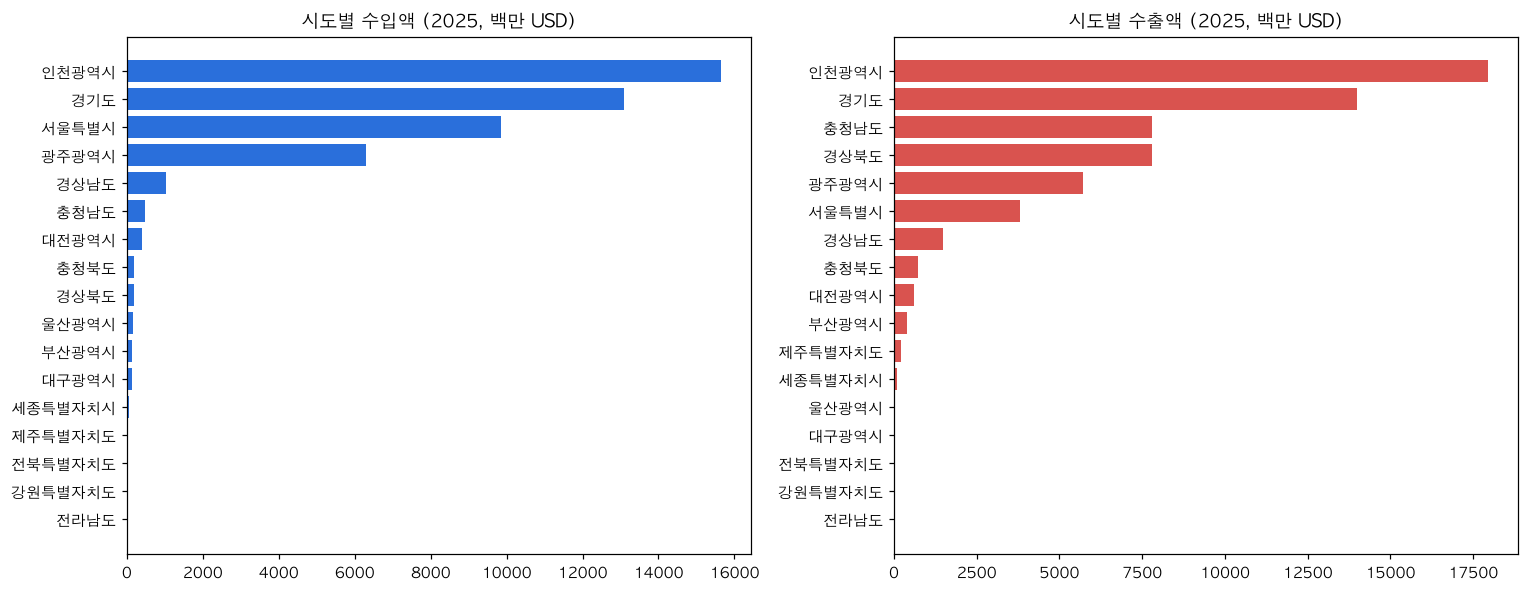

,과천시 소재 수입자 비중(추정)
category,
반도체,0.2%
소재장비,16.3%
전자부품,11.2%


In [17]:
rf = sorted(glob.glob(str(RAW / "customs" / "customs_region_*.csv")))
reg = pd.concat([pd.read_csv(f, dtype=str) for f in rf], ignore_index=True)
for c in ["impUsdAmt", "expUsdAmt"]:
    reg[c] = pd.to_numeric(reg[c].str.replace(",", ""), errors="coerce")
reg = reg[reg.priodTitle.str[:4] == "2025"].merge(wl[["hs_code", "category", "priority"]], left_on="req_hs", right_on="hs_code")
reg = reg[reg.priority.isin([1, 2])]
reg["시도"] = reg.sggNm.str.split().str[0]
print(f"지역 통계 파일 {len(rf)}개, 2025 분석 대상 행 {len(reg):,}, HS6 {reg.req_hs.nunique()}개")
# 단위 점검: 지역 통계(천 달러) 합 ≈ 국가별 통계(달러) 합 / 1,000
chk = pd.DataFrame({"지역통계 합(백만$)": reg.groupby("req_hs").impUsdAmt.sum() / 1e3,
                    "국가별통계 합(백만$)": hs_yr[hs_yr.yr == 2025].set_index("hs6").impDlr / 1e6}).dropna()
print("HS6별 지역통계/국가별통계 비율 범위:", round((chk.iloc[:, 0] / chk.iloc[:, 1]).min(), 4), "~", round((chk.iloc[:, 0] / chk.iloc[:, 1]).max(), 4))

sido = reg.groupby("시도")[["impUsdAmt", "expUsdAmt"]].sum() / 1e3   # 천 달러 → 백만 달러
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
s1 = sido.sort_values("impUsdAmt"); ax[0].barh(s1.index, s1.impUsdAmt, color=IMP); ax[0].set(title="시도별 수입액 (2025, 백만 USD)")
s2 = sido.sort_values("expUsdAmt"); ax[1].barh(s2.index, s2.expUsdAmt, color=EXP); ax[1].set(title="시도별 수출액 (2025, 백만 USD)")
plt.tight_layout(); plt.show()

gc = reg.assign(is_gc=reg.sggNm.str.contains("과천")).groupby(["category", "is_gc"]).impUsdAmt.sum().unstack(fill_value=0)
(gc[True] / gc.sum(axis=1)).rename("과천시 소재 수입자 비중(추정)").to_frame().style.format("{:.1%}")

## 8. 차이검정

검정 대상 표본은 HS6(분석 대상 13개)이다. 표본이 작고 금액 분포가 치우쳐 있으므로 먼저 **정규성(Shapiro-Wilk)** 을 확인하고, 기각되면 **비모수 검정**을 쓴다. 유의수준 α = 0.05.

| 가설 | 비교 | 검정 |
|---|---|---|
| H1 | 같은 HS6의 연평균 수입액: 2016~2020 vs 2021~2025 | 대응표본 → Wilcoxon 부호순위 (정규면 대응 t) |
| H2 | 같은 HS6의 2025 HHI: 수입 vs 수출 | 대응표본 → Wilcoxon 부호순위 (정규면 대응 t) |
| H3 | 2025 수입 HHI: 반도체 vs 그 외 품목군 | 독립 2표본 → Mann-Whitney U (정규면 Welch t) |

In [18]:
def report(name, a, b, paired):
    # 정규성 확인 후 모수/비모수 선택. 효과크기: 대응 r = Z/√n, 독립 = 순위이연 상관(비모수일 때)
    a, b = np.asarray(a, float), np.asarray(b, float)
    if paired:
        sp = stats.shapiro(a - b).pvalue
        normal = sp > .05
        t = stats.ttest_rel(a, b) if normal else stats.wilcoxon(a, b)
        test, n = ("대응 t" if normal else "Wilcoxon 부호순위"), len(a)
        r = stats.norm.isf(t.pvalue / 2) / np.sqrt(n) * np.sign(np.median(a - b))
    else:
        sp = min(stats.shapiro(a).pvalue, stats.shapiro(b).pvalue)
        normal = sp > .05
        t = stats.ttest_ind(a, b, equal_var=False) if normal else stats.mannwhitneyu(a, b, alternative="two-sided")
        test, n = ("Welch t" if normal else "Mann-Whitney U"), len(a) + len(b)
        r = np.nan if normal else 2 * t.statistic / (len(a) * len(b)) - 1
    return {"가설": name, "n": n, "정규성 p(최소)": sp, "검정": test, "통계량": t.statistic, "p값": t.pvalue,
            "효과크기 r": r, "중앙값 A": np.median(a), "중앙값 B": np.median(b),
            "판정(α=.05)": "유의" if t.pvalue < .05 else "유의하지 않음"}

tg = hs_yr[hs_yr.is_target]
p1 = tg[tg.yr.between(2016, 2020)].groupby("hs6").impDlr.mean()
p2 = tg[tg.yr.between(2021, 2025)].groupby("hs6").impDlr.mean()
pp = pd.concat([p1.rename("p1"), p2.rename("p2")], axis=1)
print("두 기간 모두 값이 있는 HS6만 대응 비교. 제외:", pp[pp.isna().any(axis=1)].index.tolist(), "(HS2022 신설 코드 — 2022년부터 존재)")
pp = pp.dropna(); p1, p2 = pp.p1, pp.p2
res = [report("H1 연평균 수입액 21~25(A) vs 16~20(B), 백만$", p2 / 1e6, p1 / 1e6, True),
       report("H2 2025 HHI 수입(A) vs 수출(B)", summ.hhi_imp, summ.hhi_exp, True),
       report("H3 2025 수입 HHI 반도체(A) vs 그 외(B)", summ.loc[summ.category == "반도체", "hhi_imp"], summ.loc[summ.category != "반도체", "hhi_imp"], False)]
tests = pd.DataFrame(res)
tests.style.format({"정규성 p(최소)": "{:.4f}", "통계량": "{:,.2f}", "p값": "{:.4f}", "효과크기 r": "{:+.2f}", "중앙값 A": "{:,.1f}", "중앙값 B": "{:,.1f}"})

두 기간 모두 값이 있는 HS6만 대응 비교. 제외: ['880730'] (HS2022 신설 코드 — 2022년부터 존재)


,가설,n,정규성 p(최소),검정,통계량,p값,효과크기 r,중앙값 A,중앙값 B,판정(α=.05)
0,"H1 연평균 수입액 21~25(A) vs 16~20(B), 백만$",12,0.0000,Wilcoxon 부호순위,26.00,0.3394,+0.28,330.2,218.5,유의하지 않음
1,H2 2025 HHI 수입(A) vs 수출(B),13,0.6824,대응 t,2.03,0.0648,+0.51,"2,533.4","1,944.4",유의하지 않음
2,H3 2025 수입 HHI 반도체(A) vs 그 외(B),13,0.0474,Mann-Whitney U,11.00,0.5734,-0.27,"2,415.4","2,838.0",유의하지 않음


In [19]:
# H1 보조: HS6별 증감 방향
chg = pd.DataFrame({"16~20 평균(백만$)": p1 / 1e6, "21~25 평균(백만$)": p2 / 1e6})
chg["변화율"] = chg.iloc[:, 1] / chg.iloc[:, 0] - 1
chg = chg.join(wl.set_index("hs_code")[["name_ko", "category"]]).sort_values("변화율", ascending=False)
print(f"증가 {int((chg.변화율 > 0).sum())}개 / 감소 {int((chg.변화율 <= 0).sum())}개 ({len(chg)}개 중)")
chg.style.format({"16~20 평균(백만$)": "{:,.1f}", "21~25 평균(백만$)": "{:,.1f}", "변화율": "{:+.1%}"})

증가 6개 / 감소 6개 (12개 중)


,16~20 평균(백만$),21~25 평균(백만$),변화율,name_ko,category
hs6,,,,,
841191,479.4,994.3,+107.4%,터보제트·터보프로펠러 부분품,소재장비
854233,219.8,415.6,+89.1%,증폭기(집적회로),반도체
854239,"4,876.6","8,844.1",+81.4%,기타 집적회로,반도체
854231,"17,181.0","29,179.0",+69.8%,프로세서·컨트롤러(집적회로),반도체
852910,195.2,253.1,+29.7%,안테나·반사식 안테나와 그 부분품,전자부품
852610,325.1,407.3,+25.3%,레이더 기기,전자부품
901490,36.3,35.4,-2.5%,항행용 기기 부분품·부속품,전자부품
901480,102.3,94.6,-7.5%,기타 항행용 기기,전자부품
901420,183.5,166.3,-9.4%,항공·우주용 항행기기,전자부품


## 9. 상관분석

### 9-1. HS6 특성 간 상관 (n = 13, 2025)

표본이 13개이고 금액이 치우쳐 있어 **Spearman 순위상관**을 기본으로 하고 p값을 함께 적는다. n = 13에서는 |ρ| ≥ 약 0.55이어야 α = 0.05에서 유의하다(19개였던 1차 EDA의 기준값은 0.46).

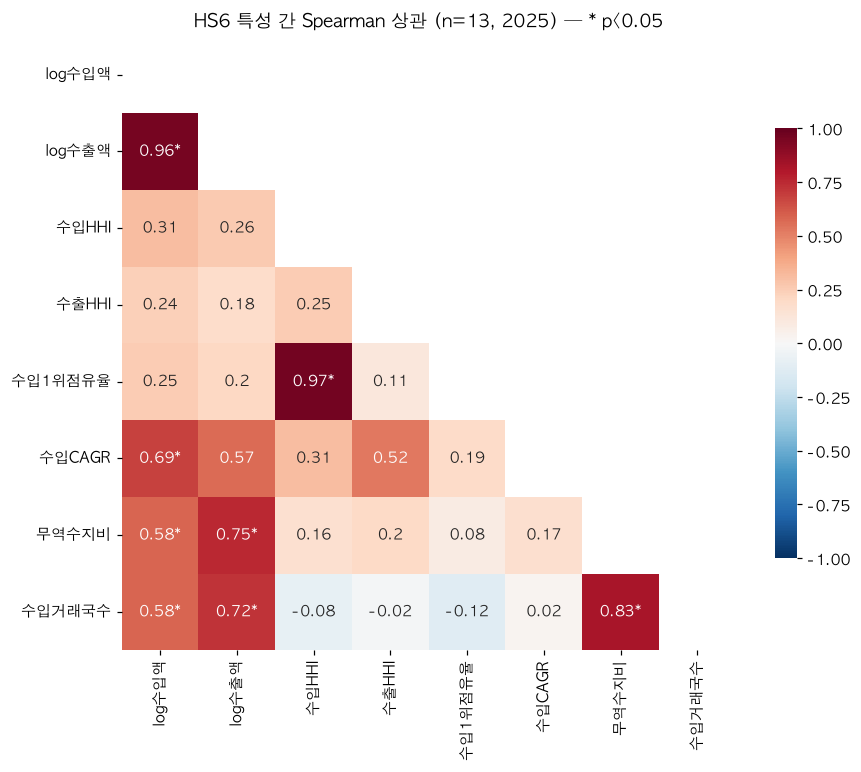

In [20]:
feat = pd.DataFrame({
    "log수입액": np.log10(summ["수입액_2025(백만$)"]),
    "log수출액": np.log10(summ["수출액_2025(백만$)"].clip(lower=1e-3)),
    "수입HHI": summ.hhi_imp, "수출HHI": summ.hhi_exp,
    "수입1위점유율": summ.top1_share_imp,
    "수입CAGR": summ.수입CAGR_16_25,
    "무역수지비": summ["무역수지비(수출-수입)/(수출+수입)"],
    "수입거래국수": summ.n_country_imp,
})
rho, p = stats.spearmanr(feat, nan_policy="omit")
rho = pd.DataFrame(rho, index=feat.columns, columns=feat.columns)
pv = pd.DataFrame(p, index=feat.columns, columns=feat.columns)
annot = rho.round(2).astype(str) + np.where(pv < .05, "*", "")
mask = np.triu(np.ones_like(rho, bool))
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(rho, mask=mask, annot=annot, fmt="", cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("HS6 특성 간 Spearman 상관 (n=13, 2025) — * p<0.05"); plt.tight_layout(); plt.show()

pairs = (rho.where(~np.tril(np.ones_like(rho, bool))).stack().rename("rho").to_frame()
         .join(pv.stack().rename("p")).dropna(subset=["rho"])
         .sort_values("rho", key=abs, ascending=False))   # pandas 3.0 stack() 은 NaN 을 남기므로 제거
pairs[pairs.p < .05].style.format({"rho": "{:+.2f}", "p": "{:.4f}"})

### 9-2. 월별 반도체 수입액 vs 생산지수 — 수준 상관과 변화율 상관

두 시계열이 모두 우상향이면 수준(level)끼리의 상관은 **추세 때문에 부풀려진다**(허구적 상관). 그래서 전년동월비(YoY) 변화율끼리의 상관을 함께 본다.

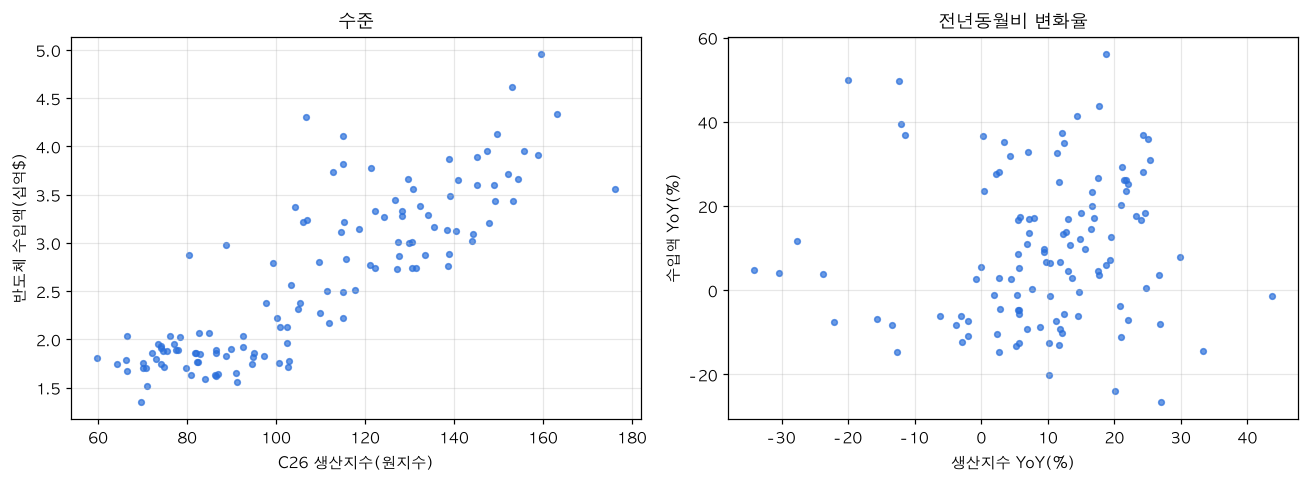

,비교,n(월),Pearson r,Pearson p,Spearman ρ,Spearman p
0,수준 (원지수 vs 수입액),127,+0.848,3.161e-36,+0.837,1.821e-34
1,전년동월비 변화율,115,+0.054,0.5646,+0.163,0.08214


In [21]:
yoy = m[["semi_imp", "prod_raw"]].pct_change(12).dropna()
rows = []
for lab, df in [("수준 (원지수 vs 수입액)", m), ("전년동월비 변화율", yoy)]:
    pr = stats.pearsonr(df.prod_raw, df.semi_imp); sr = stats.spearmanr(df.prod_raw, df.semi_imp)
    rows.append({"비교": lab, "n(월)": len(df), "Pearson r": pr.statistic, "Pearson p": pr.pvalue, "Spearman ρ": sr.statistic, "Spearman p": sr.pvalue})
corr_ts = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(m.prod_raw, m.semi_imp / 1e9, s=14, color=IMP, alpha=.7); ax[0].set(title="수준", xlabel="C26 생산지수(원지수)", ylabel="반도체 수입액(십억$)")
ax[1].scatter(yoy.prod_raw * 100, yoy.semi_imp * 100, s=14, color=IMP, alpha=.7); ax[1].set(title="전년동월비 변화율", xlabel="생산지수 YoY(%)", ylabel="수입액 YoY(%)")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()
corr_ts.style.format({"Pearson r": "{:+.3f}", "Pearson p": "{:.4g}", "Spearman ρ": "{:+.3f}", "Spearman p": "{:.4g}"})

## 10. 요약·한계

### 발견 (모두 위 셀의 실행 결과, **분석 대상 13개 기준 재실행 2026-09-22** · 로컬 원본)

19개 기준이던 1차 EDA(2026-09-19)를 09-21 회의 M5(R4 제외 → 분석 대상 13개)에 맞춰 다시 돌렸다. 값이 바뀐 항목은 옛값을 괄호에 적었다.

| # | 구분 | 내용 |
|---|---|---|
| 1 | 점검 | 원본 294,420 → 상세행 294,174 → 완결연도 276,362 → 분석 대상 13개 HS6 146,817 → 2025년 14,486행(19개 기준 옛값 191,092 → 18,532). 숫자 변환 실패·완전 중복·키 중복·음수 모두 0 |
| 2 | 기술통계 | 2025 HS6×국가 수입액은 중앙값 약 16만 달러, 평균 약 7,320만 달러, 왜도 20.4로 극단적으로 치우쳐 있다(옛값 11만·5,400만·24.2) → 시각화·검정은 로그 척도·비모수를 기본으로 한다 |
| 3 | 비교 | 규모는 반도체 집적회로가 압도적이다. 854231 프로세서·컨트롤러 수입 335.9억 달러·수출 366.8억 달러, 854239 기타 집적회로 수입 83.6억 달러. 전자부품 중 852990 통신·레이더 부분품은 수출(99.0억)이 수입(21.1억)의 약 4.7배. 13개 합계는 수입 478.2억·수출 606.6억 달러 |
| 4 | 구성 | 2025 수입 상대국 1위: 반도체 대만 52.8%(2위 일본 14.5%) / 소재장비(항공 엔진·기체 부분품) 미국 72.5% / 전자부품 중국 28.1%·베트남 26.6%(옛값 51.2·14.4 / 72.5 / 27.6·24.9). 품목군마다 주 공급국이 다르다 |
| 5 | 구성 | 수입 HHI 2,500 초과가 **13개 중 7개**, 1위국 점유율 50% 이상이 **5개**(옛값 19개 중 10개). 최고는 841191 터보제트 부분품 5,887(미국 76.4%), 901420 항공·우주 항행기기 5,774(미국 73.4%) |
| 6 | 차이검정 H1 | 2021~25 연평균 수입액이 2016~20보다 크다고 할 근거는 **유의하지 않다**(Wilcoxon, n=12, p=0.339, r=+0.28, 중앙값 330.2 vs 218.5백만$. 옛값 n=18, p=0.196). 12개 중 증가 6개(반도체 3개 모두 +69~89%)·감소 6개(항행·통신 계열)로 방향이 품목군별로 갈린다 |
| 7 | 차이검정 H2 | 같은 HS6에서 수입 HHI가 수출 HHI보다 높다는 근거는 **유의하지 않다**(대응 t, n=13, t=2.03, p=0.065, r=+0.51, 중앙값 2,533 vs 1,944). **19개 기준에서는 p=0.022로 유의했으나 13개에서는 유의수준을 넘지 못한다** — 효과크기는 중간 이상이므로 "차이가 없다"가 아니라 "13개 표본으로는 단정할 수 없다"로 읽는다 |
| 8 | 차이검정 H3 | 반도체와 그 외 품목군의 수입 HHI 차이는 **유의하지 않다**(Mann-Whitney U=11, p=0.573, r=−0.27. 옛값 p=0.368) |
| 9 | 상관 | 수입 HHI와 1위국 점유율 ρ=+0.97 → 두 지표는 사실상 같은 정보다(화면에서 둘 다 둘 필요 없음). log 수입액과 log 수출액 ρ=+0.96 → 수입이 큰 품목이 수출도 크다(같은 품목의 양방향 교역). 무역수지비와 수입거래국수 ρ=+0.83. **수입 규모와 HHI 사이에는 유의한 상관이 없다**. n=13에서는 \|ρ\| ≥ 약 0.55가 유의 기준 |
| 10 | 상관(시계열) | 반도체 월 수입액과 C26 생산지수는 수준 상관 r=+0.85(n=127)지만, 전년동월비 변화율 상관은 r=+0.05(n=115, p=0.56)이다 → 수준 상관은 **공통 상승 추세 때문**이며, 월별 변동이 함께 움직인다는 근거는 없다 |
| 11 | 공간 | 2025 수입 상대국은 대만 46.7%·일본 13.0%·중국 9.7%·미국 9.3%. 국내 신고 지역 기준 과천시(방위사업청 소재지) 소재 수입자 비중은 소재장비 16.3%·전자부품 11.2%·반도체 0.2%(추정. 전자부품 옛값 9.8%) |

### 한계·주의

- **민수 포함 국가 전체 교역**이다. HHI·점유율은 "방산 수입 의존도"가 아니다(09-21 M1 이후 「의존도」라는 말 자체를 쓰지 않는다 — 「수입 집중도」).
- 표본은 HS6 **13개**라 검정력이 더 낮아졌다. "유의하지 않음"은 "차이 없음"의 증명이 아니다 — H2가 그 예다(19개에서 유의 → 13개에서 유의하지 않음, 효과크기는 그대로 중간 이상).
- 880730은 HS2022 신설 코드라 2016~2021 값이 없다(CAGR·H1에서 제외).
- 지역 통계는 **납세의무자 소재지**라서 사용처·생산지가 아니다. 과천 비중은 추정이다.
- 2026(1~8월)은 모든 연간 비교에서 뺐다.
- 852910·901410·901490은 2026-09-19에 로컬에서 다시 수집했다(`fetch_customs.py --all-countries --hs …`). 행 수는 문서값(17,893·3,404·4,214)과 같다.
- 1차 EDA에서 언급했던 901380 기타 광학기기의 급감은 이번 범위에서 빠졌다 — 901380은 R4로만 진입했던 6개에 들어가 priority 3(배경)으로 내려갔다.
